In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

In [3]:
df = pd.read_csv("car.data", names=columns)

In [9]:
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [10]:
X = df.drop("class", axis=1)
y = df["class"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print("Coeficientes do modelo:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Coeficientes do modelo:
buying: 0.054453817089190205
maint: 0.02277519848722842
doors: -0.05388740352481004
persons: -0.32531559276963984
lug_boot: 0.0223515127350023
safety: 0.0038683786353516762


In [16]:
print("\nIntercepto:", model.intercept_)
print("\nMean Squared Error (MSE):", mse)
print("R² Score:", r2)


Intercepto: 1.8163095679421295

Mean Squared Error (MSE): 0.7338410712893654
R² Score: 0.07598883340076512


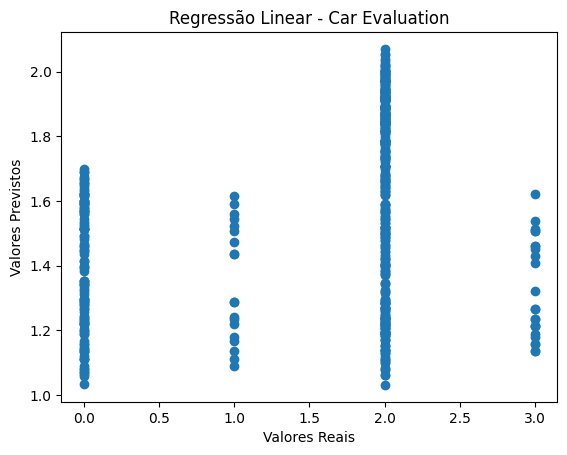

In [17]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")
plt.title("Regressão Linear - Car Evaluation")
plt.show()